# Final Model: Schedule Token + Fusion Transformer

This notebook keeps CodeBERT frozen, converts the numeric schedule features into a learned schedule token, concatenates that token with the code tokens, runs a small trainable transformer fusion block, and predicts runtime from the updated schedule token.

In [1]:
import json
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer

BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4
MAX_LENGTH = 128
RANDOM_SEED = 42
DATA_FILE = 'Cleaned_LOOPerSet_GEM(2).csv'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FEATURE_COLS = [
    'T1', 'T2', 'Unroll', 'locality', 'working_set_size',
    'arithmetic_intensity', 'T1_T2_inter', 'log_T1', 'log_T2', 'T1_div_T2'
]
FUSION_HIDDEN_SIZE = 768
FUSION_NUM_HEADS = 8
FUSION_NUM_LAYERS = 1
FUSION_DROPOUT = 0.1
BEST_MODEL_PATH = 'best_schedule_token_fusion_model.pth'
METRICS_PATH = 'schedule_token_fusion_metrics.json'

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f'[INFO] Device: {DEVICE}')

[INFO] Device: cuda


In [2]:
def compute_regression_metrics(actual_ms, predicted_ms):
    actual_ms = np.asarray(actual_ms, dtype=np.float64)
    predicted_ms = np.asarray(predicted_ms, dtype=np.float64)
    residuals = predicted_ms - actual_ms
    absolute_errors = np.abs(residuals)
    mae = float(np.mean(absolute_errors))
    rmse = float(np.sqrt(np.mean(np.square(residuals))))
    median_ae = float(np.median(absolute_errors))
    safe_actual = np.clip(np.abs(actual_ms), 1e-6, None)
    mape = float(np.mean(absolute_errors / safe_actual) * 100.0)
    ss_res = float(np.sum(np.square(residuals)))
    ss_tot = float(np.sum(np.square(actual_ms - actual_ms.mean())))
    r2 = float(1.0 - (ss_res / ss_tot)) if ss_tot > 0 else float('nan')
    return {
        'mae_ms': mae,
        'rmse_ms': rmse,
        'median_ae_ms': median_ae,
        'mape_percent': mape,
        'r2': r2,
        'residuals': residuals,
        'absolute_errors': absolute_errors,
    }


def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    predictions_log = []
    labels_log = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            schedule_features = batch['schedule_features'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            outputs = model(input_ids, attention_mask, schedule_features).squeeze(-1)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            predictions_log.append(outputs.cpu().numpy())
            labels_log.append(labels.cpu().numpy())

    predictions_log = np.concatenate(predictions_log)
    labels_log = np.concatenate(labels_log)
    predicted_ms = np.expm1(predictions_log)
    actual_ms = np.expm1(labels_log)
    metrics = compute_regression_metrics(actual_ms, predicted_ms)
    metrics['avg_loss'] = total_loss / max(len(data_loader), 1)
    metrics['predicted_ms'] = predicted_ms
    metrics['actual_ms'] = actual_ms
    return metrics

In [3]:
class CompilerDataset(Dataset):
    def __init__(self, dataframe, tokenizer, feature_means, feature_stds, max_length=128):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.feature_means = np.asarray(feature_means, dtype=np.float32)
        self.feature_stds = np.asarray(feature_stds, dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        encoding = self.tokenizer(
            row['Code_String'],
            return_tensors='pt',
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
        )
        raw_features = np.array([
            float(row['T1']),
            float(row['T2']),
            float(row['Unroll']),
            float(row['locality']),
            float(row['working_set_size']),
            float(row['arithmetic_intensity']),
            float(row['T1_T2_inter']),
            float(row['log_T1']),
            float(row['log_T2']),
            float(row['T1_div_T2']),
        ], dtype=np.float32)
        scaled_features = (raw_features - self.feature_means) / self.feature_stds
        label = float(row['log_execution_time'])
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'schedule_features': torch.tensor(scaled_features, dtype=torch.float32),
            'labels': torch.tensor(label, dtype=torch.float32),
        }

In [4]:
class ScheduleTokenFusionModel(nn.Module):
    def __init__(self, schedule_feature_size=10, hidden_size=768, num_heads=8, num_layers=1, dropout=0.1):
        super().__init__()
        self.codebert = AutoModel.from_pretrained('microsoft/codebert-base')
        self.schedule_encoder = nn.Sequential(
            nn.Linear(schedule_feature_size, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, hidden_size),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.fusion_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pre_head_norm = nn.LayerNorm(hidden_size)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, input_ids, attention_mask, schedule_features, return_fused_sequence=False):
        code_outputs = self.codebert(input_ids=input_ids, attention_mask=attention_mask)
        code_tokens = code_outputs.last_hidden_state

        schedule_token = self.schedule_encoder(schedule_features).unsqueeze(1)
        fused_tokens = torch.cat([schedule_token, code_tokens], dim=1)

        schedule_mask = torch.ones((attention_mask.size(0), 1), device=attention_mask.device, dtype=attention_mask.dtype)
        fused_attention_mask = torch.cat([schedule_mask, attention_mask], dim=1)
        key_padding_mask = fused_attention_mask == 0

        fused_sequence = self.fusion_encoder(fused_tokens, src_key_padding_mask=key_padding_mask)
        schedule_summary = self.pre_head_norm(fused_sequence[:, 0, :])
        prediction = self.regressor(schedule_summary)

        if return_fused_sequence:
            return prediction, fused_sequence, fused_attention_mask
        return prediction

In [5]:
print('[INFO] Loading tokenizer and dataset...')
tokenizer = AutoTokenizer.from_pretrained('microsoft/codebert-base')
full_df = pd.read_csv(DATA_FILE)
num_rows = len(full_df)

generator = torch.Generator().manual_seed(RANDOM_SEED)
permutation = torch.randperm(num_rows, generator=generator).tolist()
train_size = int(0.8 * num_rows)
remaining_size = num_rows - train_size
val_size = remaining_size // 2

a_idx = permutation[:train_size]
b_idx = permutation[train_size:train_size + val_size]
c_idx = permutation[train_size + val_size:]

train_df = full_df.iloc[a_idx].reset_index(drop=True)
val_df = full_df.iloc[b_idx].reset_index(drop=True)
test_df = full_df.iloc[c_idx].reset_index(drop=True)

feature_means = train_df[FEATURE_COLS].mean().to_numpy(dtype=np.float32)
feature_stds = train_df[FEATURE_COLS].std().replace(0, 1.0).to_numpy(dtype=np.float32)
feature_stats = {
    'means': feature_means.tolist(),
    'stds': feature_stds.tolist(),
    'feature_cols': FEATURE_COLS,
}

train_dataset = CompilerDataset(train_df, tokenizer, feature_means, feature_stds, max_length=MAX_LENGTH)
val_dataset = CompilerDataset(val_df, tokenizer, feature_means, feature_stds, max_length=MAX_LENGTH)
test_dataset = CompilerDataset(test_df, tokenizer, feature_means, feature_stds, max_length=MAX_LENGTH)

loader_kwargs = {'batch_size': BATCH_SIZE, 'num_workers': 2, 'pin_memory': torch.cuda.is_available()}
train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print(f'[INFO] Split sizes -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}')
print('[INFO] First three feature means:', feature_means[:3])
print('[INFO] First three feature stds:', feature_stds[:3])

[INFO] Loading tokenizer and dataset...


[INFO] Split sizes -> train: 67178, val: 8397, test: 8398
[INFO] First three feature means: [59.35086   54.305397   3.9231594]
[INFO] First three feature stds: [45.778946 43.23706   4.944218]


In [6]:
model = ScheduleTokenFusionModel(
    schedule_feature_size=len(FEATURE_COLS),
    hidden_size=FUSION_HIDDEN_SIZE,
    num_heads=FUSION_NUM_HEADS,
    num_layers=FUSION_NUM_LAYERS,
    dropout=FUSION_DROPOUT,
).to(DEVICE)

for param in model.codebert.parameters():
    param.requires_grad = False

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
criterion = nn.MSELoss()
trainable_total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'[INFO] Model ready. Trainable params: {trainable_total:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[INFO] Model ready. Trainable params: 7,288,449


/tmp/ipykernel_107938/1725360175.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.fusion_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [7]:
train_losses = []
val_losses = []
val_maes = []
val_r2s = []
learning_rates = []
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        schedule_features = batch['schedule_features'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, schedule_features).squeeze(-1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / max(len(train_loader), 1)
    val_metrics = evaluate_model(model, val_loader, criterion)

    train_losses.append(avg_train_loss)
    val_losses.append(val_metrics['avg_loss'])
    val_maes.append(val_metrics['mae_ms'])
    val_r2s.append(val_metrics['r2'])
    learning_rates.append(optimizer.param_groups[0]['lr'])

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train_loss={avg_train_loss:.4f} | val_loss={val_metrics['avg_loss']:.4f} | "
        f"val_mae={val_metrics['mae_ms']:.2f} ms | val_r2={val_metrics['r2']:.4f}"
    )

    if val_metrics['avg_loss'] < best_val_loss:
        best_val_loss = val_metrics['avg_loss']
        torch.save({'model_state_dict': model.state_dict(), 'feature_stats': feature_stats}, BEST_MODEL_PATH)
        print('  [INFO] Saved new best checkpoint.')

Epoch 01/30 | train_loss=1.9130 | val_loss=1.1550 | val_mae=451.45 ms | val_r2=0.4468
  [INFO] Saved new best checkpoint.
Epoch 02/30 | train_loss=1.2864 | val_loss=1.0378 | val_mae=385.88 ms | val_r2=0.4311
  [INFO] Saved new best checkpoint.
Epoch 03/30 | train_loss=1.2178 | val_loss=1.0600 | val_mae=392.36 ms | val_r2=0.4935
Epoch 04/30 | train_loss=1.1774 | val_loss=1.0850 | val_mae=379.61 ms | val_r2=0.4990
Epoch 05/30 | train_loss=1.1477 | val_loss=1.0143 | val_mae=397.50 ms | val_r2=0.5255
  [INFO] Saved new best checkpoint.
Epoch 06/30 | train_loss=1.1171 | val_loss=0.9868 | val_mae=414.61 ms | val_r2=0.4956
  [INFO] Saved new best checkpoint.
Epoch 07/30 | train_loss=1.1061 | val_loss=0.9499 | val_mae=368.27 ms | val_r2=0.5306
  [INFO] Saved new best checkpoint.
Epoch 08/30 | train_loss=1.0815 | val_loss=0.9690 | val_mae=377.51 ms | val_r2=0.5469
Epoch 09/30 | train_loss=1.0663 | val_loss=0.9508 | val_mae=412.07 ms | val_r2=0.4643
Epoch 10/30 | train_loss=1.0527 | val_loss=0.9

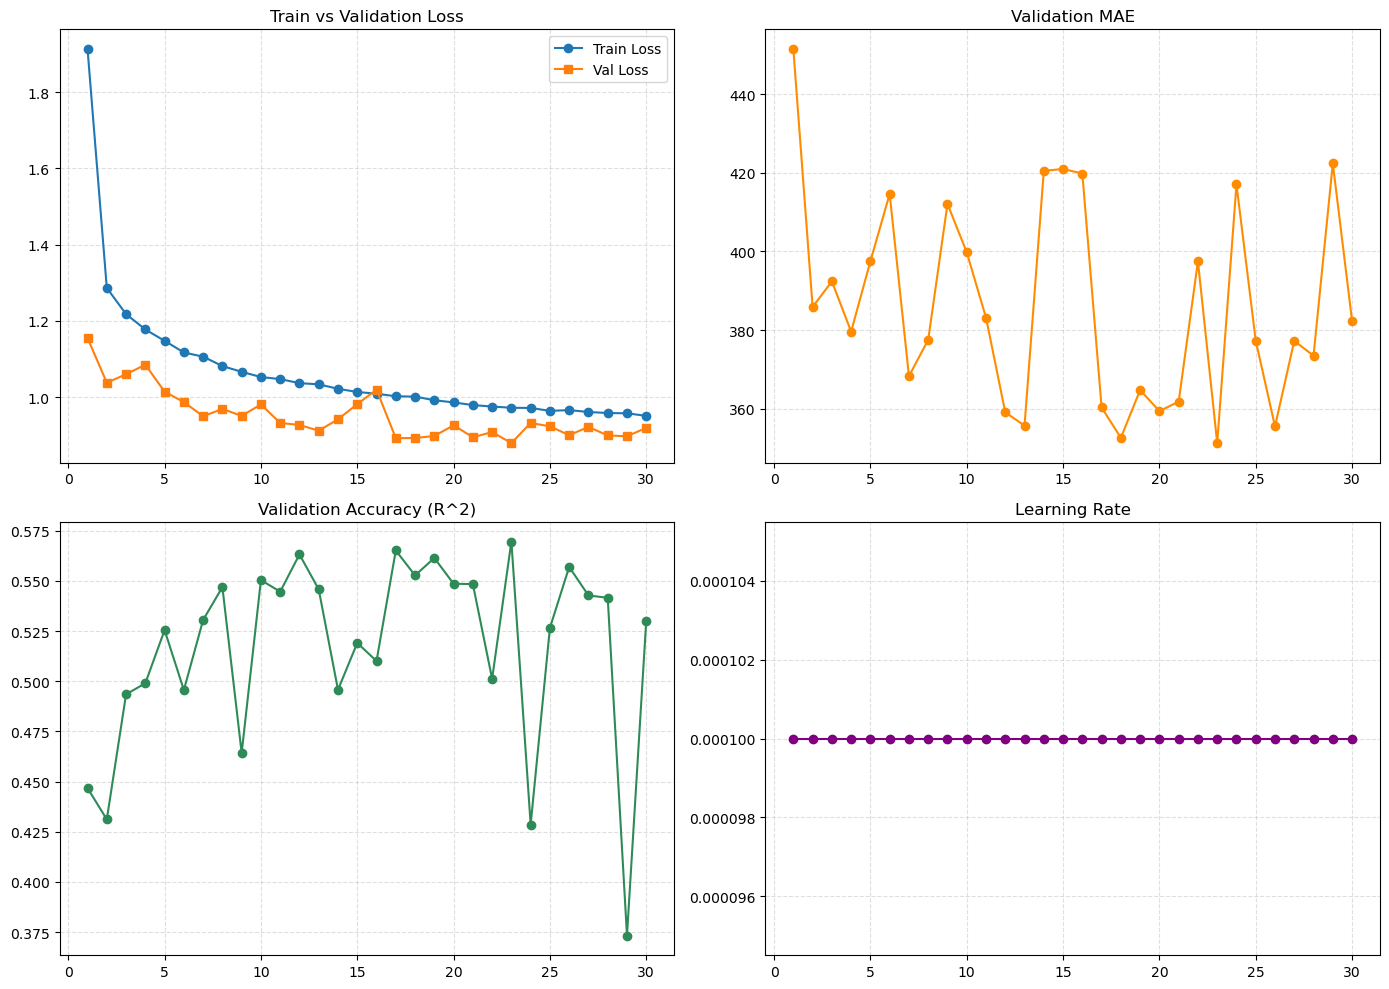

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs = range(1, EPOCHS + 1)

axes[0, 0].plot(epochs, train_losses, marker='o', label='Train Loss')
axes[0, 0].plot(epochs, val_losses, marker='s', label='Val Loss')
axes[0, 0].set_title('Train vs Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.4)

axes[0, 1].plot(epochs, val_maes, marker='o', color='darkorange')
axes[0, 1].set_title('Validation MAE')
axes[0, 1].grid(True, linestyle='--', alpha=0.4)

axes[1, 0].plot(epochs, val_r2s, marker='o', color='seagreen')
axes[1, 0].set_title('Validation Accuracy (R^2)')
axes[1, 0].grid(True, linestyle='--', alpha=0.4)

axes[1, 1].plot(epochs, learning_rates, marker='o', color='purple')
axes[1, 1].set_title('Learning Rate')
axes[1, 1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [9]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print('[INFO] Best checkpoint reloaded for test evaluation.')

test_metrics = evaluate_model(model, test_loader, criterion)
metrics_to_save = {
    'mae_ms': test_metrics['mae_ms'],
    'rmse_ms': test_metrics['rmse_ms'],
    'median_ae_ms': test_metrics['median_ae_ms'],
    'mape_percent': test_metrics['mape_percent'],
    'r2': test_metrics['r2'],
}
with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics_to_save, f, indent=2)

print('Test metrics:')
for key, value in metrics_to_save.items():
    if 'percent' in key:
        print(f'  {key}: {value:.2f}')
    else:
        print(f'  {key}: {value:.4f}')

[INFO] Best checkpoint reloaded for test evaluation.
Test metrics:
  mae_ms: 376.3718
  rmse_ms: 1646.0476
  median_ae_ms: 20.1666
  mape_percent: 155.32
  r2: 0.5060


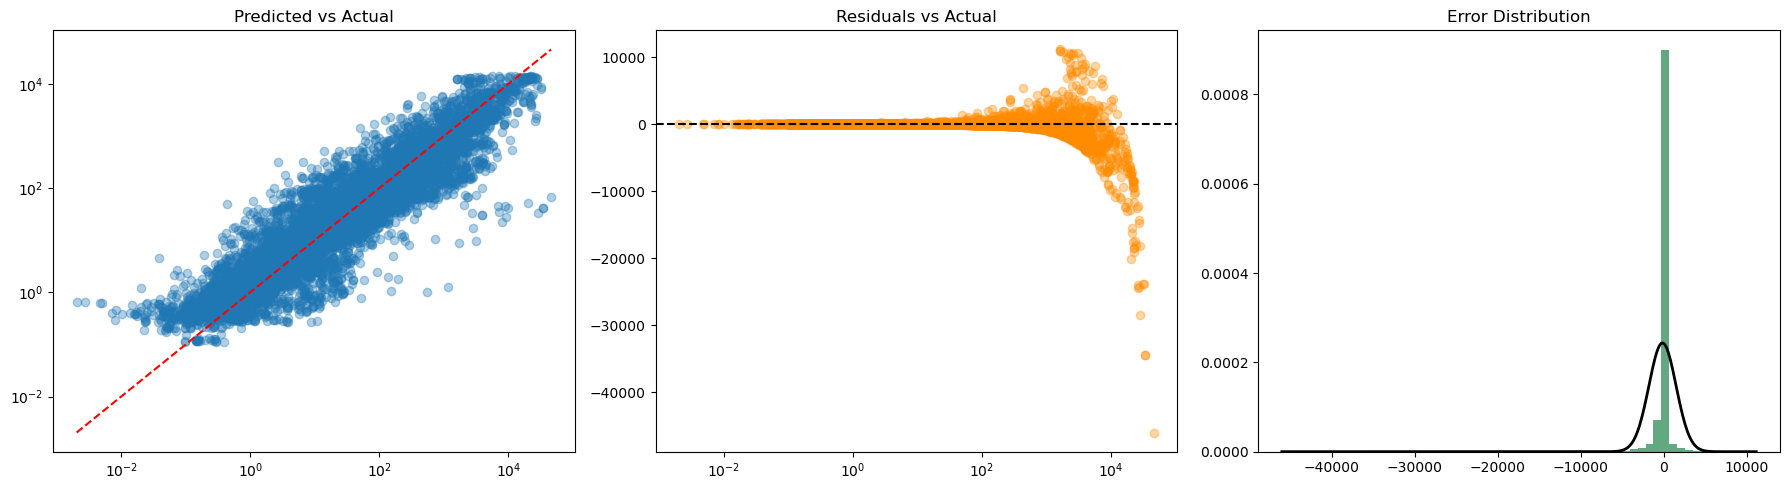

In [10]:
actual_ms = test_metrics['actual_ms']
predicted_ms = test_metrics['predicted_ms']
residuals = test_metrics['residuals']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(actual_ms, predicted_ms, alpha=0.35)
min_val = max(min(actual_ms.min(), predicted_ms.min()), 1e-6)
max_val = max(actual_ms.max(), predicted_ms.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Predicted vs Actual')

axes[1].scatter(actual_ms, residuals, alpha=0.35, color='darkorange')
axes[1].axhline(0.0, color='black', linestyle='--')
axes[1].set_xscale('log')
axes[1].set_title('Residuals vs Actual')

axes[2].hist(residuals, bins=60, density=True, alpha=0.75, color='seagreen')
mu = residuals.mean()
sigma = residuals.std() if residuals.std() > 0 else 1.0
x = np.linspace(residuals.min(), residuals.max(), 400)
gaussian = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
axes[2].plot(x, gaussian, color='black', linewidth=2)
axes[2].set_title('Error Distribution')

plt.tight_layout()
plt.show()

In [11]:
error_df = test_df.copy().reset_index(drop=True)
error_df['actual_ms'] = test_metrics['actual_ms']
error_df['predicted_ms'] = test_metrics['predicted_ms']
error_df['absolute_error_ms'] = np.abs(error_df['predicted_ms'] - error_df['actual_ms'])

runtime_bins = [0, 1, 10, 100, 1000, 10000, np.inf]
runtime_labels = ['<=1 ms', '1-10 ms', '10-100 ms', '100 ms-1 s', '1-10 s', '>10 s']
error_df['runtime_bucket'] = pd.cut(error_df['actual_ms'], bins=runtime_bins, labels=runtime_labels, include_lowest=True)

bucket_summary = error_df.groupby('runtime_bucket', observed=False).agg(
    count=('actual_ms', 'size'),
    mae_ms=('absolute_error_ms', 'mean'),
    median_ae_ms=('absolute_error_ms', 'median'),
).reset_index()

print('Worst 10 predictions by absolute error:')
display(error_df[['Code_String', 'actual_ms', 'predicted_ms', 'absolute_error_ms', 'T1', 'T2', 'Unroll']].sort_values('absolute_error_ms', ascending=False).head(10))
print('Runtime bucket summary:')
display(bucket_summary)

Worst 10 predictions by absolute error:


,Code_String,actual_ms,predicted_ms,absolute_error_ms,T1,T2,Unroll
2113,for (int i0=1; i0<129; i0++) {\n for (int i1=...,46099.398438,67.980064,46031.417969,0,0,1
6351,for (int i0=0; i0<320; i0++) {\n for (int i1=...,34437.812500,42.530426,34395.281250,0,0,1
1225,for (int i0=0; i0<320; i0++) {\n for (int i1=...,34437.812500,42.530426,34395.281250,0,0,1
3132,for (int i0=0; i0<128; i0++) {\n for (int i1=...,28558.193359,34.124794,28524.068359,0,0,1
2015,for (int i0=0; i0<1536; i0++) {\n for (int i1...,26613.509766,2198.745361,24414.763672,128,64,8
4700,for (int i0=0; i0<1536; i0++) {\n for (int i1...,26902.796875,2548.447021,24354.349609,128,64,4
8232,for (int i0=0; i0<1024; i0++) {\n for (int i1...,25904.792969,1968.411865,23936.380859,0,0,1
6411,for (int i0=0; i0<512; i0++) {\n for (int i1=...,32008.007812,8092.561035,23915.447266,128,32,1
1819,for (int i0=0; i0<512; i0++) {\n for (int i1=...,32592.607422,8779.125000,23813.482422,64,128,1
8362,for (int i0=0; i0<320; i0++) {\n for (int i1=...,20161.892578,51.113869,20110.779297,0,0,1


Runtime bucket summary:


,runtime_bucket,count,mae_ms,median_ae_ms
0,<=1 ms,1117,1.006836,0.371343
1,1-10 ms,1815,8.180439,1.875568
2,10-100 ms,2251,39.721630,17.063744
3,100 ms-1 s,2248,228.290497,113.996536
4,1-10 s,869,1798.476807,1106.080322
5,>10 s,98,9992.976562,7519.211426
